### MULTI-DIMENSIONAL TYPOLOGY

In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [2]:
# IMPORTS AND RELOAD CONSOLIDATED OD DATA
OUTPUT_DIR = Path('OUTPUT')
STATIONS = ['TLC','BMR','BSN','KTW','CTK','WSN','BKH','TSH','LAK','KHA','DMG','LHK','RST']

csv_files = sorted(OUTPUT_DIR.glob('od_*.csv'))
od = pd.concat([pd.read_csv(f) for f in csv_files], ignore_index=True)

od['service_date_ce'] = pd.to_datetime(od['service_date_ce'])
od['is_weekend'] = od['service_date_ce'].dt.dayofweek >= 5

print(f"SHAPE: {od.shape}")

SHAPE: (1234038, 7)


In [4]:
# RECOMPUTE WEEKDAY STATION METRICS
n_weekday_days = od[od['is_weekend']==False]['service_date_ce'].nunique()
print(f"Weekday days: {n_weekday_days}")

station_metrics = []
for station in STATIONS:
    entries = od[(od['origin']==station) & (od['is_weekend']==False)].groupby('hour_start')['count'].sum()
    exits = od[(od['destination']==station) & (od['is_weekend']==False)].groupby('hour_start')['count'].sum()

    entries_avg = entries / n_weekday_days
    exits_avg = exits / n_weekday_days

    daily_entry_total = entries_avg.sum()
    daily_exit_total = exits_avg.sum()

    station_metrics.append({
        'station': station,
        'daily_entry_total': daily_entry_total,
        'daily_exit_total': daily_exit_total,
        'am_peak_hr': entries_avg.idxmax(),
        'am_peak_share': entries_avg.max() / daily_entry_total,
        'pm_peak_hr': exits_avg.idxmax(),
        'pm_peak_share': exits_avg.max() / daily_exit_total,
        'entry_peak_to_mean': entries_avg.max()/entries_avg.mean(),
        'exit_peak_to_mean': exits_avg.max()/exits_avg.mean(),
    })

metrics_df = pd.DataFrame(station_metrics)
print(metrics_df)

Weekday days: 260
   station  daily_entry_total  daily_exit_total  am_peak_hr  am_peak_share  \
0      TLC         992.442308        998.700000           7       0.171097   
1      BMR         607.680769        641.642308           7       0.167560   
2      BSN         496.769231        536.838462           8       0.149295   
3      KTW        8321.157692       8902.896154          18       0.131719   
4      CTK         585.476923        702.976923          17       0.145483   
5      WSN        1019.180769       1001.726923          17       0.199681   
6      BKH        1877.719231       1824.203846          17       0.199448   
7      TSH         624.557692        632.792308          18       0.187671   
8      LAK        3766.557692       3866.000000          17       0.130999   
9      KHA         776.692308        750.003846           7       0.209845   
10     DMG        6038.134615       5110.350000           7       0.089204   
11     LHK        1789.276923       1659.76153

In [5]:
# DEMAND-PROFILE CLUSTERING FOR STATION TYPOLOGY
# Build feature matrix from the above table metrics
features = metrics_df[['am_peak_share','pm_peak_share','entry_peak_to_mean','exit_peak_to_mean','daily_entry_total']].copy()
features_scaled = StandardScaler().fit_transform(features)

# Try k=3 and k=4 clusters
for k in [3,4]:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(features_scaled)
    print(f"\n--- k={k} ---")
    for station, label in zip(metrics_df['station'], labels):
        print(f"  {station}: cluster {label}")


--- k=3 ---
  TLC: cluster 0
  BMR: cluster 0
  BSN: cluster 0
  KTW: cluster 2
  CTK: cluster 0
  WSN: cluster 1
  BKH: cluster 1
  TSH: cluster 1
  LAK: cluster 2
  KHA: cluster 1
  DMG: cluster 2
  LHK: cluster 0
  RST: cluster 1

--- k=4 ---
  TLC: cluster 0
  BMR: cluster 0
  BSN: cluster 0
  KTW: cluster 1
  CTK: cluster 0
  WSN: cluster 3
  BKH: cluster 3
  TSH: cluster 2
  LAK: cluster 1
  KHA: cluster 2
  DMG: cluster 1
  LHK: cluster 0
  RST: cluster 2


In [6]:
# SHAPE-ONLY CLUSTERING (EXCLUDE VOLUME)
shape_features = metrics_df[['am_peak_share','pm_peak_share','entry_peak_to_mean','exit_peak_to_mean']].copy()
shape_scaled = StandardScaler().fit_transform(shape_features)

for k in [3,4]:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(shape_scaled)
    print(f"\n--- k={k} (shape-only) ---")
    for station, label in zip(metrics_df['station'], labels):
        print(f"  {station}: cluster {label}")


--- k=3 (shape-only) ---
  TLC: cluster 0
  BMR: cluster 0
  BSN: cluster 0
  KTW: cluster 2
  CTK: cluster 2
  WSN: cluster 1
  BKH: cluster 1
  TSH: cluster 0
  LAK: cluster 2
  KHA: cluster 1
  DMG: cluster 2
  LHK: cluster 2
  RST: cluster 0

--- k=4 (shape-only) ---
  TLC: cluster 0
  BMR: cluster 0
  BSN: cluster 1
  KTW: cluster 1
  CTK: cluster 1
  WSN: cluster 2
  BKH: cluster 2
  TSH: cluster 0
  LAK: cluster 1
  KHA: cluster 0
  DMG: cluster 3
  LHK: cluster 1
  RST: cluster 0


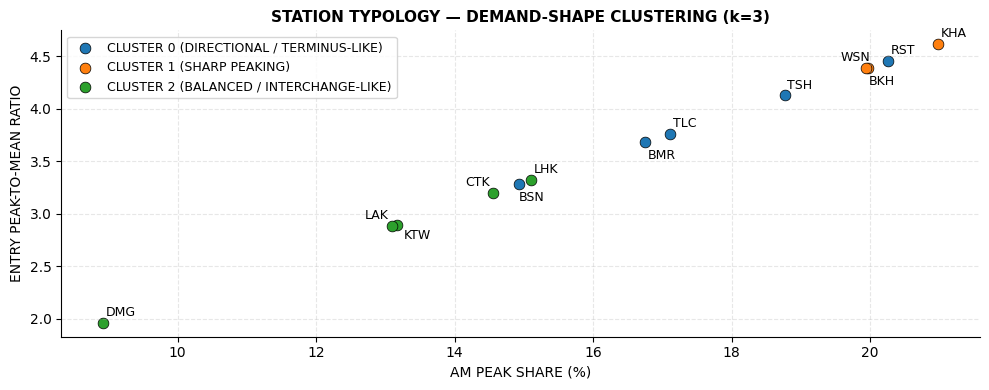

In [36]:
# FIGURE: AM PEAK SHARE VS ENTRY PEAK-TO-MEAN RATIO, COLORED BY SHAPE-ONLY CLUSTER (k=3)
km3 = KMeans(n_clusters=3, random_state=42, n_init=10)
metrics_df['cluster'] = km3.fit_predict(shape_scaled)

fig, ax = plt.subplots(figsize=(10, 4))

cluster_colors = {0: 'tab:blue', 1: 'tab:orange', 2: 'tab:green'}
cluster_labels = {0: 'CLUSTER 0 (DIRECTIONAL / TERMINUS-LIKE)',
                  1: 'CLUSTER 1 (SHARP PEAKING)',
                  2: 'CLUSTER 2 (BALANCED / INTERCHANGE-LIKE)'}

label_offsets = {
    'TLC': (2, 5),
    'BMR': (2, -12),
    'BSN': (0, -12),
    'KTW': (5, -10),
    'CTK': (-20, 5),
    'WSN': (-20, 5),
    'BKH': (2, -12),
    'TSH': (2, 5),
    'LAK': (-20, 5),
    'KHA': (2, 5),
    'DMG': (2, 5),
    'LHK': (2, 5),
    'RST': (2, 5),
}

for c in sorted(metrics_df['cluster'].unique()):
    sub = metrics_df[metrics_df['cluster']==c]
    ax.scatter(sub['am_peak_share']*100, sub['entry_peak_to_mean'], color=cluster_colors[c], label=cluster_labels[c], s=60, edgecolor='k', linewidth=0.5)

for _, row in metrics_df.iterrows():
    dx, dy = label_offsets.get(row['station'], (5, 3))
    ax.annotate(row['station'], (row['am_peak_share']*100, row['entry_peak_to_mean']), xytext=(dx, dy), textcoords='offset points', fontsize=9)

ax.set_xlabel('AM PEAK SHARE (%)')
ax.set_ylabel('ENTRY PEAK-TO-MEAN RATIO')
ax.set_title('STATION TYPOLOGY — DEMAND-SHAPE CLUSTERING (k=3)', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, linestyle='--', alpha=0.3)

sns.despine()
plt.tight_layout()
plt.savefig('OUTPUT/station_typology_clusters.png', dpi=300)
plt.show()

In [7]:
# VOLUME-INCLUSIVE TYPOLOGY SUMMARY (k=3) FOR TABLE 9
km_vol = KMeans(n_clusters=3, random_state=42, n_init=10)
metrics_df['volume_cluster'] = km_vol.fit_predict(features_scaled)

print("STATION ASSIGNMENTS (volume-inclusive, k=3)")
for station, cluster in zip(metrics_df['station'], metrics_df['volume_cluster']):
    print(f"  {station}: cluster {cluster}")

print("\nCLUSTER SUMMARY (mean values)")
summary = metrics_df.groupby('volume_cluster')[['daily_entry_total','am_peak_share','pm_peak_share','entry_peak_to_mean','exit_peak_to_mean']].mean()
print(summary)

print("\nSTATIONS PER CLUSTER")
for c in sorted(metrics_df['volume_cluster'].unique()):
    stations = metrics_df[metrics_df['volume_cluster']==c]['station'].tolist()
    print(f"  Cluster {c}: {', '.join(stations)}")

STATION ASSIGNMENTS (volume-inclusive, k=3)
  TLC: cluster 0
  BMR: cluster 0
  BSN: cluster 0
  KTW: cluster 2
  CTK: cluster 0
  WSN: cluster 1
  BKH: cluster 1
  TSH: cluster 1
  LAK: cluster 2
  KHA: cluster 1
  DMG: cluster 2
  LHK: cluster 0
  RST: cluster 1

CLUSTER SUMMARY (mean values)
                daily_entry_total  am_peak_share  pm_peak_share  \
volume_cluster                                                    
0                      894.329231       0.156894       0.136734   
1                     1637.870769       0.199846       0.180822   
2                     6041.950000       0.117307       0.122931   

                entry_peak_to_mean  exit_peak_to_mean  
volume_cluster                                         
0                         3.451677           3.008144  
1                         4.396606           3.978082  
2                         2.580761           2.704489  

STATIONS PER CLUSTER
  Cluster 0: TLC, BMR, BSN, CTK, LHK
  Cluster 1: WSN, BKH, TSH, K

___
**END**